# Exploratory Data Analysis (EDA) — Transaction Analysis

## Objective

This notebook performs Exploratory Data Analysis (EDA) on the cleaned **transaction** dataset from the banking analytics project.

The objective is to analyze customer transaction behavior, transaction channels, merchant activity, fraud patterns, and overall transaction performance. The analysis helps identify transaction trends, customer payment preferences, operational performance, and potential risk areas within the banking system.

The cleaned datasets prepared during the Data Cleaning phase are used throughout this notebook.

> **Note:** Customer, Account, Branch, Merchant, Loan, Card, and Complaint analysis are covered in separate notebooks.

---

## Business Questions Covered in This Notebook

### Transaction Analysis

* What is the distribution of transaction types?
* How does transaction volume change over time?
* Which transaction channels are used most frequently?
* Which merchant categories process the highest number of transactions?
* Which cities generate the highest transaction volume?
* What is the distribution of transaction statuses?
* How do fraudulent transactions trend over time?

---

## Expected Outcome

By the end of this notebook, valuable insights will be obtained into transaction patterns, customer payment behavior, channel usage, merchant activity, fraud trends, and transaction performance. These findings support business decision-making and serve as the foundation for building interactive Tableau dashboards in the final phase of the project.


## Import Libraries

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

## Loading the Cleaned Datasets

In [54]:
customers=pd.read_csv("data/Cleaned/dim_customers.csv")
accounts=pd.read_csv("data/Cleaned/dim_accounts.csv")
cards=pd.read_csv("data/Cleaned/dim_cards.csv")
merchants=pd.read_csv("data/Cleaned/dim_merchants.csv")
dates=pd.read_csv("data/Cleaned/dim_date.csv")
transactions=pd.read_csv("data/Cleaned/fact_transactions.csv")

## Preview of Transaction Dataset

In [55]:
transactions.head()

,transaction_id,date_id,account_id,card_id,merchant_id,amount,transaction_type,channel,city,status,is_fraud,mdr_revenue,transaction_fee
0,SAL0289407,20220101,ACC033291,NaN,MER02633,34509.99,Deposit,Bank Transfer,Kolkata,Completed,False,0.0,0.0
1,SAL0563049,20220101,ACC064646,NaN,MER02081,29056.48,Deposit,Bank Transfer,Jaipur,Completed,False,0.0,0.0
2,TXN0379705,20220101,ACC215134,CRD244383,MER00568,1223.20,Purchase,ATM,Hyderabad,Completed,False,0.0,0.0
3,TXN0095155,20220101,ACC024154,CRD252211,MER02069,27858.24,Withdrawal,POS,Kolkata,Completed,False,0.0,0.0
4,SAL0815040,20220101,ACC094046,NaN,MER02142,25644.37,Deposit,Bank Transfer,Jaipur,Completed,False,0.0,0.0


## Question 1: What are the most common transaction types?

In [56]:
transactions['transaction_type'].value_counts()

transaction_type
Deposit       1417776
Purchase       660056
Transfer       239893
Withdrawal     180070
Name: count, dtype: int64

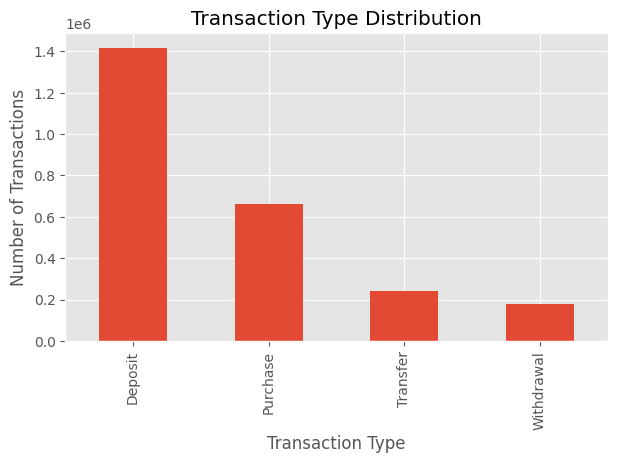

In [57]:
transactions['transaction_type'].value_counts().plot(kind='bar',figsize=(7,4));
plt.title('Transaction Type Distribution');
plt.xlabel('Transaction Type');
plt.ylabel('Number of Transactions');plt.show()

### Observation

Different transaction types indicate how customers use banking services.

## Question 2: What is the distribution of transaction amounts?

In [58]:
transactions['amount'].describe()

count    2.497795e+06
mean     5.380280e+04
std      2.516229e+05
min     -1.970345e+07
25%      2.424580e+03
50%      2.356837e+04
75%      6.267147e+04
max      2.678984e+07
Name: amount, dtype: float64

In [59]:
# Checking for negative amounts (data quality check)
negative_count = (transactions['amount'] < 0).sum()
print("Number of transactions with a negative amount:", negative_count)
print("Percentage of total transactions:", round(negative_count / len(transactions) * 100, 3), "%")

Number of transactions with a negative amount: 12470
Percentage of total transactions: 0.499 %


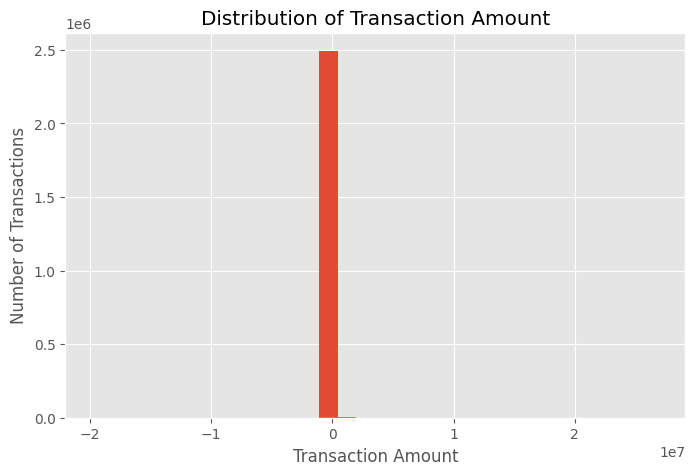

In [60]:
plt.figure(figsize=(8,5));
plt.hist(transactions['amount'],bins=30);
plt.title('Distribution of Transaction Amount');
plt.xlabel('Transaction Amount');
plt.ylabel('Number of Transactions');
plt.show()

### Observation

Most transactions are of smaller amounts (the median is much lower than the mean), while a few very large and even **negative** amounts exist in the data.

Because of these extreme values, the average transaction amount is pulled higher than what a "typical" transaction actually looks like. This means the **median is a more reliable measure of a typical transaction** than the mean for this column. The negative values may be refunds/reversals or data entry issues and would be worth checking with the data source team.

## Question 3: Which transaction channels are used the most?

In [61]:
transactions['channel'].value_counts()

channel
Bank Transfer    1284914
Online            417577
POS               354678
Mobile App        236256
ATM               179379
Name: count, dtype: int64

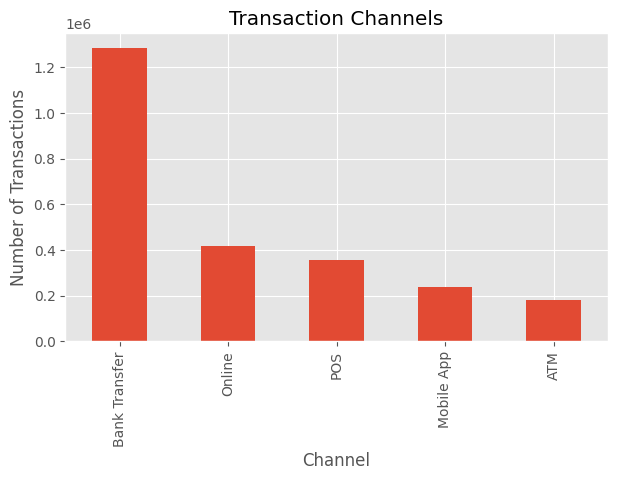

In [62]:
transactions['channel'].value_counts().plot(kind='bar',figsize=(7,4));
plt.title('Transaction Channels');
plt.xlabel('Channel');
plt.ylabel('Number of Transactions');
plt.show()

### Observation

Customers use multiple banking channels.

## Question 4: How do transactions change over time?

In [63]:
transactions['date_id']=pd.to_datetime(transactions['date_id'].astype(str),format='%Y%m%d')
monthly=transactions.groupby(transactions['date_id'].dt.to_period('M')).size()
monthly

date_id
2022-01     43791
2022-02     33276
2022-03     44622
2022-04     43264
2022-05     45699
2022-06     44882
2022-07     48113
2022-08     50103
2022-09     48748
2022-10     66101
2022-11     60022
2022-12     65361
2023-01     56836
2023-02     47325
2023-03     59085
2023-04     59127
2023-05     60895
2023-06     61688
2023-07     65284
2023-08     67118
2023-09     67237
2023-10     82305
2023-11     81499
2023-12     86034
2024-01     77643
2024-02     70227
2024-03     82537
2024-04     81686
2024-05     84944
2024-06     87542
2024-07     90501
2024-08     94815
2024-09     95702
2024-10    111151
2024-11    113936
2024-12    118696
Freq: M, dtype: int64

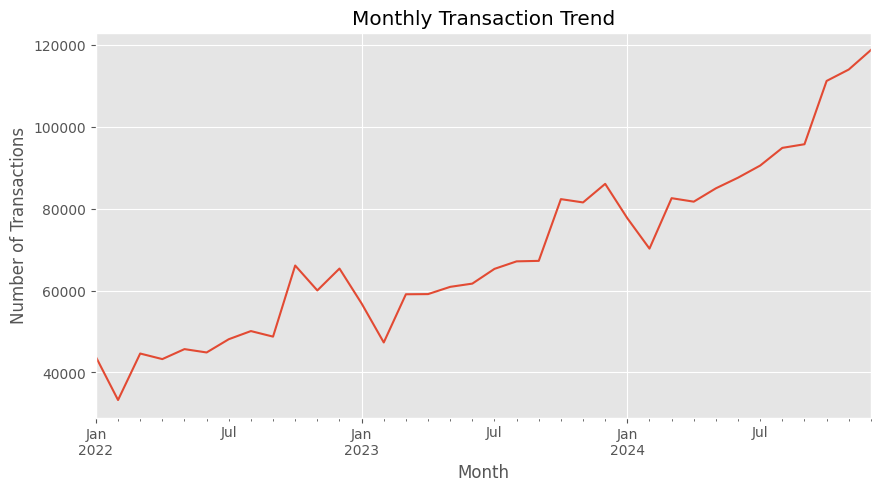

In [64]:
monthly.plot(figsize=(10,5));plt.title('Monthly Transaction Trend');plt.xlabel('Month');plt.ylabel('Number of Transactions');plt.show()

### Observation

Monthly trends help identify seasonal patterns.

## Question 5: What percentage of transactions are fraudulent?

In [65]:
transactions['is_fraud'].value_counts()

is_fraud
False    2495314
True        2481
Name: count, dtype: int64

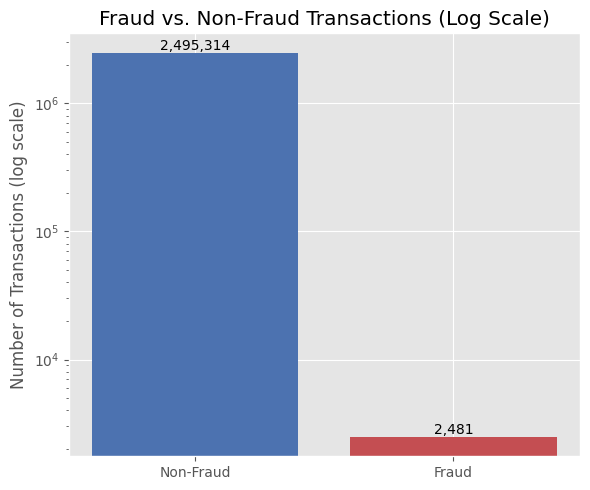

In [66]:
fraud_counts = transactions['is_fraud'].value_counts()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(["Non-Fraud", "Fraud"], fraud_counts.values, color=["#4C72B0", "#C44E52"])
ax.set_yscale("log")
ax.set_title("Fraud vs. Non-Fraud Transactions (Log Scale)")
ax.set_ylabel("Number of Transactions (log scale)")

for bar, val in zip(bars, fraud_counts.values):
    ax.annotate(f"{val:,}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

### Observation

Only a small percentage of transactions are fraudulent.

## Question 6: Which cities have the highest number of transactions?

In [67]:
top=transactions['city'].value_counts().head(10)
top

city
Kochi         307453
Jaipur        259365
Hyderabad     257173
Lucknow       237040
Bangalore     204515
Kolkata       200748
Mumbai        151192
Delhi         141352
Chandigarh    137086
Pune          133893
Name: count, dtype: int64

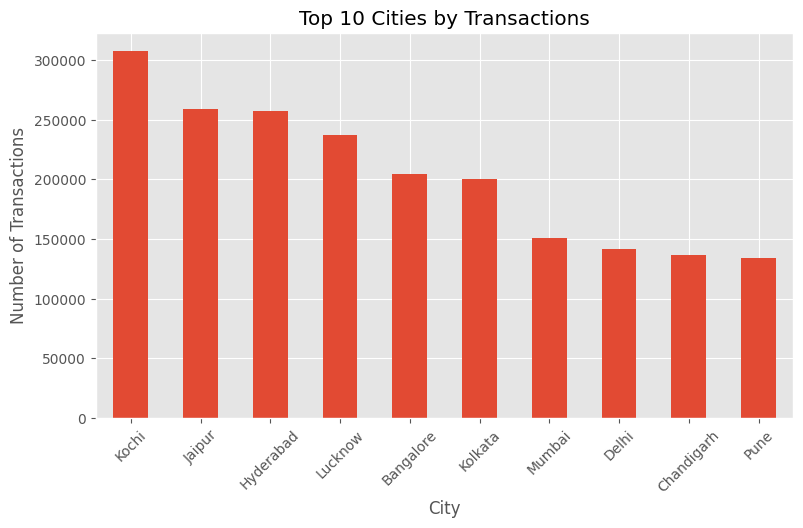

In [68]:
top.plot(kind='bar',figsize=(9,5));plt.title('Top 10 Cities by Transactions');plt.xlabel('City');plt.ylabel('Number of Transactions');plt.xticks(rotation=45);plt.show()

### Observation

Top cities contribute a large share of transactions.

## Question 7: Which merchants process the highest number of transactions?

In [69]:
merchant = transactions['merchant_id'].value_counts().head(10)
merchant

merchant_id
MER01544    6431
MER01885    6428
MER01293    6403
MER00516    6395
MER01695    6389
MER01331    6367
MER02915    6360
MER02203    6359
MER02304    6353
MER03270    6352
Name: count, dtype: int64

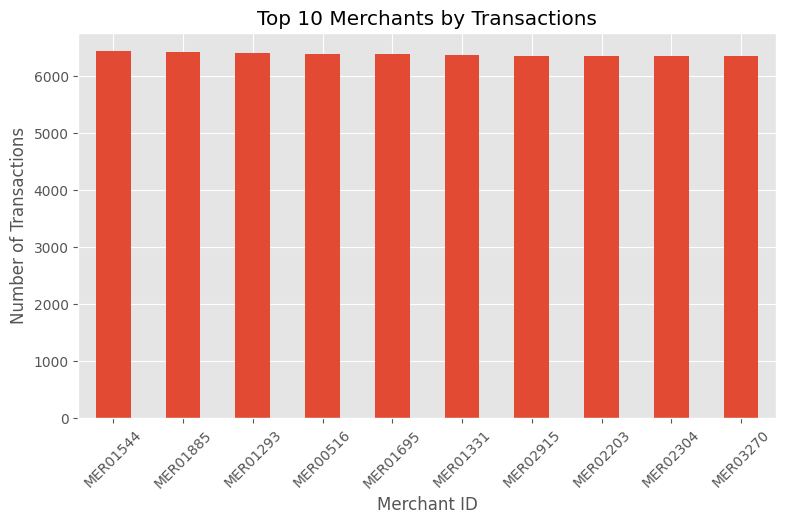

In [70]:
merchant.plot(kind='bar',figsize=(9,5));plt.title('Top 10 Merchants by Transactions');plt.xlabel('Merchant ID');plt.ylabel('Number of Transactions');plt.xticks(rotation=45);plt.show()

### Observation

A few merchants process significantly more transactions.

## Question 8: How much MDR revenue is generated?

In [71]:
transactions['mdr_revenue'].describe()

count    2.497795e+06
mean     2.261050e+01
std      1.264415e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.368502e+04
Name: mdr_revenue, dtype: float64

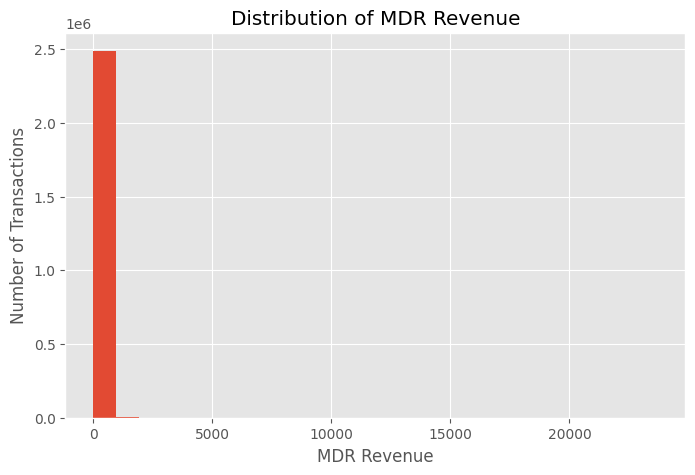

In [72]:
plt.figure(figsize=(8,5));plt.hist(transactions['mdr_revenue'],bins=25);plt.title('Distribution of MDR Revenue');plt.xlabel('MDR Revenue');plt.ylabel('Number of Transactions');plt.show()

### Observation

Most transactions have an MDR revenue of 0 (the median and 75th percentile are both 0). Only a smaller subset of transactions actually generate MDR revenue, which is why the histogram is concentrated near zero with a long tail of higher values.

## Question 9: How are transaction fees distributed?

In [73]:
transactions['transaction_fee'].describe()

count    2.497795e+06
mean     2.364504e-01
std      1.800320e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.499000e+01
Name: transaction_fee, dtype: float64

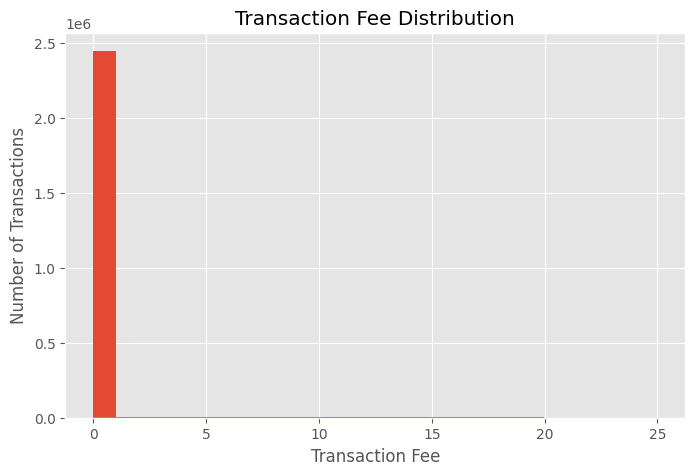

In [74]:
plt.figure(figsize=(8,5));plt.hist(transactions['transaction_fee'],bins=25);plt.title('Transaction Fee Distribution');plt.xlabel('Transaction Fee');plt.ylabel('Number of Transactions');plt.show()

### Observation

Transaction fees are also mostly 0 (median and 75th percentile are both 0). This suggests that only certain transaction types are charged a fee, while others (such as Deposits and Purchases, confirmed later in Question 17) are fee-free.

## Question 10: Which transaction channel is used for fraudulent transactions?

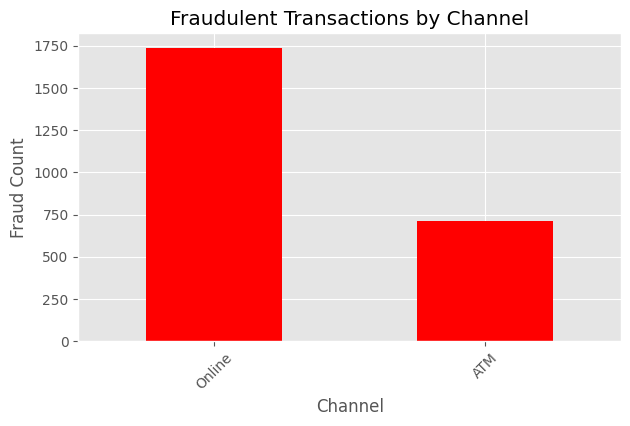

In [75]:
fraud_channel=transactions[transactions['is_fraud']==True]['channel'].value_counts()
fraud_channel.plot(kind='bar', figsize=(7,4), color='red')
plt.title('Fraudulent Transactions by Channel')
plt.xlabel('Channel')
plt.ylabel('Fraud Count')
plt.xticks(rotation=45)
plt.show()

### Observation

Fraudulent transactions only occur through the **Online** (1,738 cases) and **ATM** (714 cases) channels in this dataset. No fraud is recorded for Bank Transfer, Mobile App, or POS channels. This suggests fraud monitoring efforts should be focused on Online and ATM channels specifically.

## Question 14: Which transaction type has the highest fraud count?

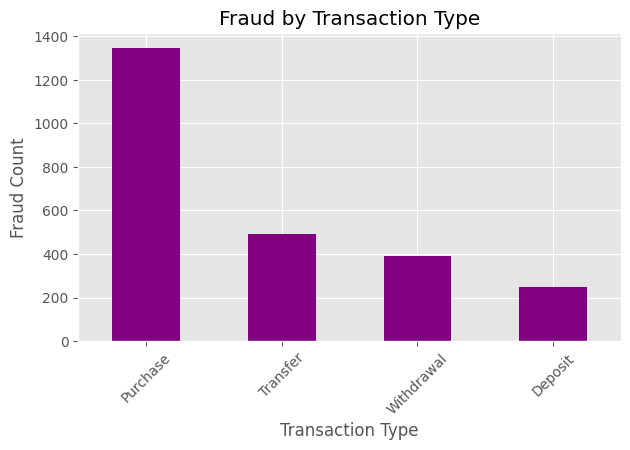

In [76]:
fraud_type=transactions[transactions['is_fraud']==True]['transaction_type'].value_counts()
fraud_type.plot(kind='bar', figsize=(7,4), color='purple')
plt.title('Fraud by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Count')
plt.xticks(rotation=45)
plt.show()

### Observation

**Purchase** transactions have the highest fraud count (1,348), followed by Transfer (495), Withdrawal (391), and Deposit (249). This indicates that fraud is more common in transactions where money is being spent or moved out, rather than in deposits.

## Question 18: What is the monthly fraud trend?

In [77]:
fraud_only = transactions[transactions['is_fraud'] == True]
monthly_fraud = fraud_only.groupby(fraud_only['date_id'].dt.to_period('M')).size()
monthly_fraud

date_id
2022-01     68
2022-02     50
2022-03     73
2022-04     53
2022-05     83
2022-06     50
2022-07     70
2022-08     57
2022-09     68
2022-10     85
2022-11     81
2022-12     94
2023-01     64
2023-02     46
2023-03     75
2023-04     60
2023-05     57
2023-06     68
2023-07     69
2023-08     63
2023-09     53
2023-10    110
2023-11     66
2023-12     94
2024-01     74
2024-02     49
2024-03     65
2024-04     52
2024-05     67
2024-06     67
2024-07     54
2024-08     71
2024-09     77
2024-10     80
2024-11     75
2024-12     93
Freq: M, dtype: int64

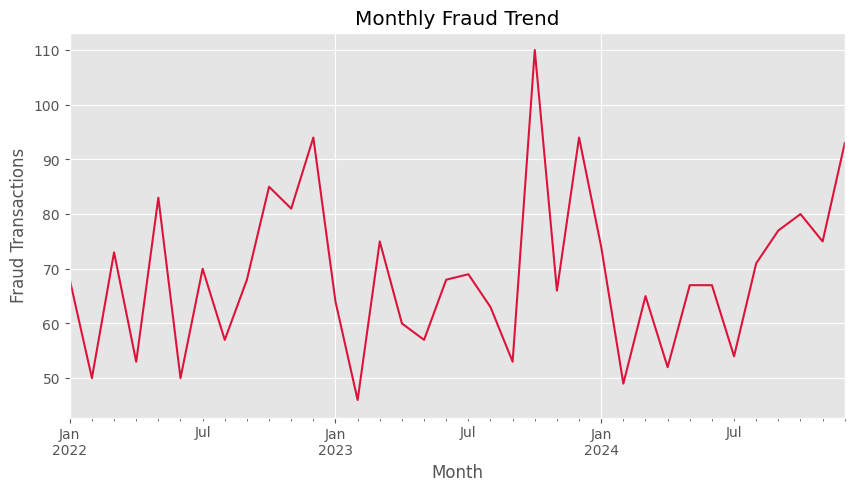

In [78]:
monthly_fraud.plot(figsize=(10,5), color='crimson')
plt.title('Monthly Fraud Trend')
plt.xlabel('Month')
plt.ylabel('Fraud Transactions')
plt.show()

### Observation

The number of fraud cases per month fluctuates between roughly 46 and 94, without a clear long-term upward or downward trend. This suggests fraud activity is fairly steady over time rather than rapidly increasing, though continued monthly monitoring is still recommended.

# Transaction Analysis Summary

- Transaction types analyzed
- Transaction amount distribution analyzed
- Channel usage analyzed
- Monthly trends analyzed
- Fraud analysis completed
- City-wise and merchant-wise analysis completed
- MDR revenue and transaction fee analysis completed
- Transaction status analysis completed

The dataset is now ready for dashboard development.